In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [16]:
load_dotenv()

True

In [17]:
model = ChatGroq(
    model='openai/gpt-oss-20b'
)

In [18]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    review: str

In [19]:
def create_outline(state: BlogState) -> BlogState:
    #fetch_title
    title = state['title']

    #call llm and genarate outline
    prompt = f'Genarate a detailed outline for a blogon the topic - {title}'
    outline = model.invoke(prompt).content

    #update state
    state['outline'] = outline

    return state

In [20]:
def create_blog(state: BlogState) -> BlogState:
    #fetch_title and current outline
    title = state['title']
    outline = state['outline']

    #call llm and genarate outline
    prompt = f'Genarate a detailed blog from the title - {title} using the following outline \n{outline}'

    content = model.invoke(prompt).content

    #update state
    state['content'] = content

    return state

In [21]:
def review(state: BlogState) -> BlogState:
    #fetch_title and current outline
    title = state['title']
    outline = state['outline']
    content = state['content']

    #call llm and genarate outline
    prompt = f'Genarate a review for the blog based on the following content \n{content}, Give the content a score out of 10'

    review = model.invoke(prompt).content

    #update state
    state['review'] = review

    return state

In [22]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('review', review)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog' )
graph.add_edge('create_blog','review')
graph.add_edge('review', END)

In [23]:
workflow = graph.compile()

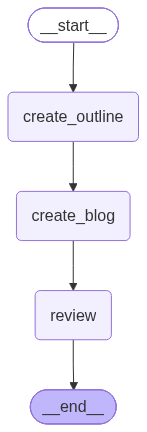

In [24]:
workflow

In [25]:
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

In [26]:
final_state

{'title': 'Rise of AI in India',
 'outline': '## Blog Outline  \n**Title Ideas (pick one or mix‑and‑match)**  \n- “From Silicon Valley to Silicon Valley: The Rise of AI in India”  \n- “AI in India: A New Dawn for Innovation, Growth, and Governance”  \n- “How India Is Becoming the World’s AI Powerhouse”  \n\n---\n\n### 1. Hook & Hook‑Line  \n- Start with a striking statistic or anecdote (e.g., “India’s AI market is projected to reach $10\u202fbn by 2025—an 80% jump from 2021”).  \n- Pose a provocative question: *“What if India’s next tech boom is not about chips, but about algorithms?”*  \n- Mention a recent headline (e.g., “India’s first AI‑driven smart city unveiled in Bengaluru”).\n\n---\n\n### 2. Introduction  \n- Brief overview of AI and why it matters globally.  \n- State the thesis: **India is rapidly emerging as a leading AI ecosystem, driven by policy, talent, and real‑world impact.**  \n- Outline what the reader will learn: history, current landscape, key sectors, success stor

In [27]:
print(final_state['outline'])

## Blog Outline  
**Title Ideas (pick one or mix‑and‑match)**  
- “From Silicon Valley to Silicon Valley: The Rise of AI in India”  
- “AI in India: A New Dawn for Innovation, Growth, and Governance”  
- “How India Is Becoming the World’s AI Powerhouse”  

---

### 1. Hook & Hook‑Line  
- Start with a striking statistic or anecdote (e.g., “India’s AI market is projected to reach $10 bn by 2025—an 80% jump from 2021”).  
- Pose a provocative question: *“What if India’s next tech boom is not about chips, but about algorithms?”*  
- Mention a recent headline (e.g., “India’s first AI‑driven smart city unveiled in Bengaluru”).

---

### 2. Introduction  
- Brief overview of AI and why it matters globally.  
- State the thesis: **India is rapidly emerging as a leading AI ecosystem, driven by policy, talent, and real‑world impact.**  
- Outline what the reader will learn: history, current landscape, key sectors, success stories, challenges, and future prospects.

---

### 3. Historical Contex

In [28]:

print(final_state['content'])

# AI in India: A New Dawn for Innovation, Growth, and Governance  

> *“India’s AI market is projected to reach $10 bn by 2025—an 80 % jump from 2021.”*  
> *“What if India’s next tech boom is not about chips, but about algorithms?”*  

---

## 1. Hook & Hook‑Line  

India’s AI journey is no longer a quiet side‑project. It’s a headline‑making reality. The first AI‑driven smart city was unveiled in Bengaluru, and the government’s “AI for All” policy has turned the country into a fertile ground for data‑driven innovation. As the world watches, the question is: **How is India transforming its vast, diverse data into a global AI powerhouse?**  

---

## 2. Introduction  

Artificial Intelligence—once a futuristic buzzword—has become a cornerstone of economic growth, public welfare, and competitive advantage. From automated diagnostics in rural clinics to predictive maintenance in steel mills, AI is reshaping every sector.  

**Thesis:** *India is rapidly emerging as a leading AI ecosystem,

In [29]:
print(final_state['review'])

**Blog Review – “AI in India: A New Dawn for Innovation, Growth, and Governance”**

---

### 1. Quick Snapshot

| Element | Assessment |
|---------|------------|
| **Title & Hook** | Strong, provocative. The tagline “What if India’s next tech boom is not about chips, but about algorithms?” instantly grabs attention. |
| **Structure** | Clear, logical flow from historical context to future outlook. The use of tables and bullet points keeps the reader oriented. |
| **Depth** | The post balances breadth (policy, academia, industry, sectors) with depth (case studies, data snapshots). |
| **Visuals** | Suggested visuals are well‑chosen, though the actual post would benefit from incorporating them. |
| **Tone** | Conversational yet authoritative, suitable for a professional audience. |
| **Overall Score** | **8.5 / 10** |

---

### 2. What Works Well

| Feature | Why It Matters |
|---------|----------------|
| **Hook & Hook‑Line** | The opening paragraph immediately frames India’s AI traject